In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import sklearn 
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
# =====================================================
# Load Train-Test Dataset (CSV)
# =====================================================



# Load feature matrices
X_train = pd.read_csv("/workspaces/pcf-quality-framework/BEACON-PCF/data/X_train.csv")
X_test = pd.read_csv("/workspaces/pcf-quality-framework/BEACON-PCF/data/X_test.csv")

# Load target variables
y_train = pd.read_csv("/workspaces/pcf-quality-framework/BEACON-PCF/data/y_train.csv").squeeze()
y_test = pd.read_csv("/workspaces/pcf-quality-framework/BEACON-PCF/data/y_test.csv").squeeze()

print("Train/Test Shapes")
print("-" * 30)
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)





Train/Test Shapes
------------------------------
X_train: (692, 34)
X_test : (174, 34)
y_train: (692,)
y_test : (174,)


In [3]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

In [4]:
from sklearn.preprocessing import StandardScaler

numeric_features = [
    "Company",
    "Product_Weight"
]

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Fit scaler ONLY on training data
X_train_scaled[numeric_features] = scaler.fit_transform(
    X_train[numeric_features]
)

# Apply the same scaler to test data
X_test_scaled[numeric_features] = scaler.transform(
    X_test[numeric_features]
)

StandardScaler is applied only to the continuous numerical features
(Company and Product_Weight) as value are not in range. Linear models are sensitive to feature
scale, whereas one-hot encoded binary features do not require scaling.



After one-hot encoding, you'll have around 60–80 features (depending on the categories).

Your dataset has 866 samples.

This is not a high-dimensional dataset. PCA is generally more useful when you have hundreds or thousands of correlated numerical features (e.g., images, gene expression data, text embeddings). With your structured tabular data, PCA may:

reduce interpretability,
mix one-hot encoded categorical features into principal components,
make it harder to explain the model in your dissertation,
and may not improve prediction performance.

Most tree-based models you're planning to use (Random Forest, XGBoost, CatBoost) do not benefit from PCA.

In [5]:

# Model Performance Table
# =====================================================

results = pd.DataFrame(
    columns=[
        "Model",
        "MAE",
        "RMSE",
        "R2_Original",
        "R2_Log"
    ]
)

# Model 1 : Linear Regression

In [6]:

# Model 1 : Linear Regression
# =====================================================

from sklearn.linear_model import LinearRegression
from sklearn.metrics import PredictionErrorDisplay

In [7]:
# Initialize model
lr = LinearRegression()
lr.fit(
    X_train_scaled,
    y_train_log
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](34,)","[ 0.14, 0.02, 0. ,...,-0.07,-0.55, 2.38]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](34,)","['Year','Company','Stage_Level_CO2e_Available',...,'Region_South America', 'Region_South Asia','Region_Southeast Asia']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-282
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,34
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(33)


In [8]:
# Prediction on log scale
y_pred_log = lr.predict(X_test_scaled)

# Convert predictions back to original PCF scale
y_pred = np.expm1(y_pred_log)


In [9]:


print("y_test")
print("NaN:", np.isnan(y_test).sum())
print("Inf:", np.isinf(y_test).sum())
print("Max:", np.max(y_test))

print("\ny_pred_log")
print("NaN:", np.isnan(y_pred_log).sum())
print("Inf:", np.isinf(y_pred_log).sum())
print("Max:", np.max(y_pred_log))

print("\ny_pred")
print("NaN:", np.isnan(y_pred).sum())
print("Inf:", np.isinf(y_pred).sum())
print("Max:", np.max(y_pred))

y_test
NaN: 0
Inf: 0
Max: 99075.0

y_pred_log
NaN: 0
Inf: 0
Max: 14.200191987022038

y_pred
NaN: 0
Inf: 0
Max: 1469145.2195878217


In [10]:
score = lr.score(X_test, y_test)
score

0.1062411539475453

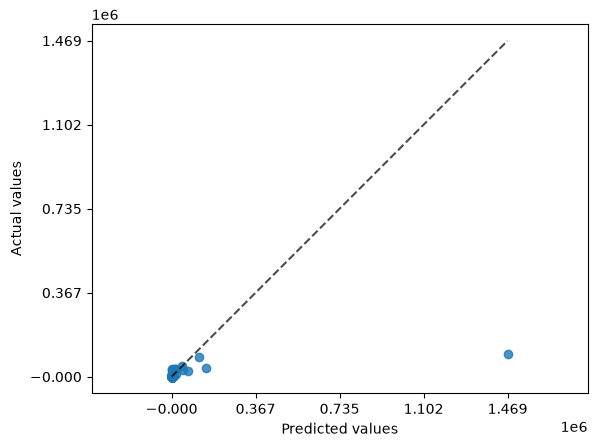

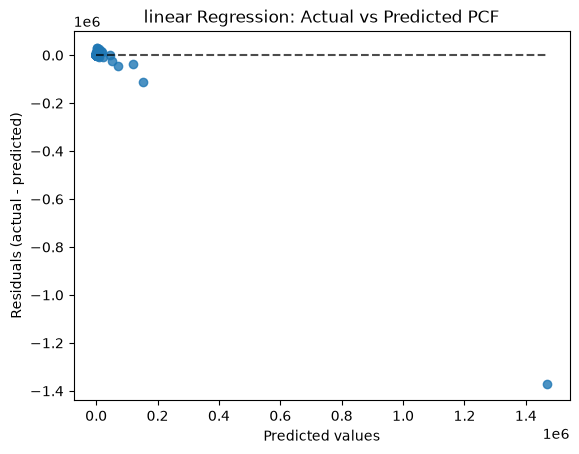

In [11]:

PredictionErrorDisplay.from_predictions(
    y_test,
    y_pred,
    kind="actual_vs_predicted"
).plot()

plt.title("linear Regression: Actual vs Predicted PCF")
plt.show()

In [12]:
print("Maximum log prediction:", y_pred_log.max())
print("Maximum original prediction:", y_pred.max())

idx = np.argmax(y_pred)

print("\nProblematic prediction:")
print("Actual:", y_test.iloc[idx])
print("Log prediction:", y_pred_log[idx])
print("Original prediction:", y_pred[idx])

Maximum log prediction: 14.200191987022038
Maximum original prediction: 1469145.2195878217

Problematic prediction:
Actual: 99075.0
Log prediction: 14.200191987022038
Original prediction: 1469145.2195878217


Linear Regression performs reasonably on the log-transformed target (R² = 0.642) but performs poorly on the original PCF scale because errors in log predictions can become very large when transformed back using expm1().

In [13]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test,y_pred))

r2_original = r2_score(y_test,y_pred)

r2_log = r2_score(y_test_log,y_pred_log)

In [14]:
print("=" * 60)
print("Linear Regression (Baseline)")
print("=" * 60)

print(f"MAE (Original Scale)       : {mae:,.2f}")
print(f"RMSE (Original Scale)      : {rmse:,.2f}")
print(f"R² (Original Scale)        : {r2_original:.4f}")
print(f"R² (Log-transformed Scale) : {r2_log:.4f}")

Linear Regression (Baseline)
MAE (Original Scale)       : 10,777.89
RMSE (Original Scale)      : 104,438.21
R² (Original Scale)        : -70.8860
R² (Log-transformed Scale) : 0.6420


R² compares your model against simply predicting the mean of y_test.

One prediction is:

Actual       = 99,075
Predicted    = 1,469,145
Error        ≈ -1,370,070

That enormous error gets squared when calculating R² and RMSE.

That's why you have:

RMSE = 104,438
R²   = -70.886

The single extreme prediction has a very large influence.

But why is MAE only 10,777?

Because MAE doesn't square the errors. Most of your observations appear to have much smaller errors, while that one extreme prediction is dominating the squared-error metrics.

Your log R² tells a different story

You have:

R² (Log scale) = 0.642

That's actually reasonably meaningful. It means the Linear Regression model explains about 64.2% of the variance in the log-transformed PCF target.

The problem occurs when you convert:

y_pred_log

back to:

y_pred = np.expm1(y_pred_log)

because the exponential transformation magnifies large log-scale predictions.

So your interpretation should be:

Linear Regression achieved an R² of 0.642 on the log-transformed target but a negative R² of −70.886 on the original scale. The negative original-scale R² is largely driven by extreme prediction errors after transforming the predictions back from the logarithmic scale, including a prediction of approximately 1.47 million for an actual PCF of 99,075.

In [15]:
results.loc[len(results)] = [
    "Linear Regression(Baseline)",
    mae,
    rmse,
    r2_original,
    r2_log
]

results

,Model,MAE,RMSE,R2_Original,R2_Log
0,Linear Regression(Baseline),10777.889157,104438.206531,-70.886024,0.642036


Yes — **now your calculations are on the correct scales**. However, the model's **original-scale performance is still poor**, while its log-scale performance is reasonable.

Your results:

| Metric      |       Result | Interpretation  |
| ----------- | -----------: | --------------- |
| MAE         |    10,777.89 | High            |
| RMSE        |   104,438.21 | Very high       |
| R² Original | **-70.8860** | Very poor       |
| R² Log      |   **0.6420** | Reasonably good |

### The important part

Your `R² Log = 0.6420` means the Linear Regression explains about **64.2% of the variance in the log-transformed PCF target**.

But:

```text
R² Original = -70.886
```

means that when you convert predictions back to the original PCF scale, the model performs very poorly.

This is **possible and not necessarily a coding error**, especially because your PCF target is extremely right-skewed:

```text
Skewness = 17.63
```

You have some very large PCF values, so a few bad predictions can make the original-scale RMSE and R² extremely poor.

### Your next step

Since you are comparing models, I would **keep both metrics**:

```text
R² (Log-transformed Scale)
R² (Original Scale)
MAE (Original Scale)
RMSE (Original Scale)
```

Then compare Linear Regression with Ridge, XGBoost, CatBoost, etc.

Based on the results you showed earlier, **XGBoost is performing much better than Linear Regression** on both scales.

For example, your earlier XGBoost result was approximately:

```text
XGBoost:
MAE Original       = 1,924.84
RMSE Original      = 8,445.93
R² Original        = 0.5299
R² Log             = 0.9392
```

compared with Linear Regression:

```text
Linear Regression:
MAE Original       = 10,777.89
RMSE Original      = 104,438.21
R² Original        = -70.8860
R² Log             = 0.6420
```

So **the Linear Regression result is now technically valid, but it is a weak model for your dataset**.

One thing I would check before moving on is **why the Linear Regression's original-scale predictions are so extreme**. A residual/predicted-vs-actual plot would help diagnose that.


Just be transparent in your methodology that scaling was performed after the train/test split and before cross-validation.

Your test set remains completely untouched.

Ridge Regression

ridge = Ridge(
    alpha=1.0,
    random_state=42
)

In [16]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0,random_state=42
)

In [17]:
ridge.fit(
    X_train_scaled,
    y_train_log
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary <random_state>` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",42
,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"pos

In [18]:
y_pred_log = ridge.predict(
    X_test_scaled
)

y_pred = np.expm1(
    y_pred_log
)

In [19]:
score = ridge.score(X_test, y_test_log)
score

-428157.6246931897

In [20]:
mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mean_squared_error(y_test,y_pred))
r2_original = r2_score(y_test,y_pred)
r2_log = r2_score(y_test_log,y_pred_log)

In [21]:
print("=" * 60)
print("Ridge Regression")
print("=" * 60)

print(f"RMSE (Original Scale)      : {rmse:,.2f}")
print(f"MAE (Original Scale)       : {mae:,.2f}")
print(f"R² (Original Scale)        : {r2_original:.4f}")
print(f"R² (Log-transformed Scale) : {r2_log:.4f}")

Ridge Regression
RMSE (Original Scale)      : 94,236.54
MAE (Original Scale)       : 10,378.10
R² (Original Scale)        : -57.5281
R² (Log-transformed Scale) : 0.6493


In [22]:
results.loc[len(results)] = [
    "Ridge Regression",
    rmse,
    mae,
    r2_original,
    r2_log
]

results

,Model,MAE,RMSE,R2_Original,R2_Log
0,Linear Regression(Baseline),10777.889157,104438.206531,-70.886024,0.642036
1,Ridge Regression,94236.544159,10378.101724,-57.528090,0.649315


In [ ]:
# Grid Search for Ridge Regression
param_grid = {
    "alpha": [0.01, 0.1, 1, 10, 100]
}

grid = GridSearchCV(
    estimator = Ridge(),
    param_grid = param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_scaled, y_train_log)

print("Best Parameters:", grid.best_params_)
print("Best CV Score :", grid.best_score_)

Best Parameters: {'alpha': 1}
Best CV Score : 0.6928811744406481


In [24]:
best_ridge = grid.best_estimator_

In [25]:
y_pred_log = best_ridge.predict(X_test_scaled)

y_pred = np.expm1(y_pred_log)

In [26]:
score = best_ridge.score(X_test, y_test_log)
score

-428157.6246931897

In [27]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2_original = r2_score(y_test, y_pred)

r2_log = r2_score(y_test_log, y_pred_log)

In [28]:
print("=" * 60)
print("Ridge Regression")
print("=" * 60)

print(f"MAE (Original Scale)       : {mae:,.2f}")
print(f"RMSE (Original Scale)      : {rmse:,.2f}")
print(f"R² (Original Scale)        : {r2_original:.4f}")
print(f"R² (Log-transformed Scale) : {r2_log:.4f}")

Ridge Regression
MAE (Original Scale)       : 10,378.10
RMSE (Original Scale)      : 94,236.54
R² (Original Scale)        : -57.5281
R² (Log-transformed Scale) : 0.6493


In [29]:
results.loc[len(results)] = [
    "Ridge Regression (grid search)",
    mae,
    rmse,
    r2_original,
    r2_log
]
results

,Model,MAE,RMSE,R2_Original,R2_Log
0,Linear Regression(Baseline),10777.889157,104438.206531,-70.886024,0.642036
1,Ridge Regression,94236.544159,10378.101724,-57.528090,0.649315
2,Ridge Regression (grid search),10378.101724,94236.544159,-57.528090,0.649315


In [ ]:
# Randomized Search for Ridge Regression

param_dist = {
    "alpha": [0.01, 0.1, 1, 10, 100]
}

random_search = RandomizedSearchCV(
    estimator=Ridge(),
    param_distributions=param_dist,
    n_iter=30,    # Test 30 random combinations
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train_log)

print("Best Parameters:", random_search.best_params_)
print("Best CV Score:", random_search.best_score_)

/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/model_selection/_search.py:326: UserWarning: The total space of parameters 5 is smaller than n_iter=30. Running 5 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best Parameters: {'alpha': 1}
Best CV Score: 0.6928911221375558


In [31]:
best_ridge = random_search . best_estimator_

y_pred_log = best_ridge.predict(X_test)

y_pred = np.expm1(y_pred_log)

In [32]:
score = best_ridge.score(X_test, y_test_log)

print(f"score:{score}")

score:0.6497085242014393


In [33]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2_original = r2_score(y_test, y_pred)

r2_log = r2_score(y_test_log, y_pred_log)

In [34]:
print("=" * 60)
print("Ridge Regression(Randomized Search)")
print("=" * 60)

print(f"MAE (Original Scale)       : {mae:,.2f}")
print(f"RMSE (Original Scale)      : {rmse:,.2f}")
print(f"R² (Original Scale)        : {r2_original:.4f}")
print(f"R² (Log-transformed Scale) : {r2_log:.4f}")

Ridge Regression(Randomized Search)
MAE (Original Scale)       : 10,609.87
RMSE (Original Scale)      : 97,029.17
R² (Original Scale)        : -61.0484
R² (Log-transformed Scale) : 0.6497


In [35]:
results.loc[len(results)] = [
    "Ridge Regression(Randomized Search)",
    mae,
    rmse,
    r2_original,
    r2_log
]
results

,Model,MAE,RMSE,R2_Original,R2_Log
0,Linear Regression(Baseline),10777.889157,104438.206531,-70.886024,0.642036
1,Ridge Regression,94236.544159,10378.101724,-57.528090,0.649315
2,Ridge Regression (grid search),10378.101724,94236.544159,-57.528090,0.649315
3,Ridge Regression(Randomized Search),10609.874195,97029.165858,-61.048351,0.649709


# SVR


In [36]:
from sklearn.svm import SVR


In [37]:
svr = SVR()
svr.fit(X_train_scaled, y_train_log)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [38]:
y_pred_log = svr.predict(X_test_scaled)
y_pred = np.expm1(y_pred_log)

In [39]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2_original = r2_score(y_test, y_pred)

r2_log = r2_score(y_test_log, y_pred_log)

In [40]:
print("="*60)
print("SVR (Baseline)")
print("="*60)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Original: {r2_original:.4f}")
print(f"R² Log: {r2_log:.4f}")

SVR (Baseline)
MAE : 3960.78
RMSE: 12911.85
R² Original: -0.0988
R² Log: -0.0006


In [ ]:
results.loc[len(results)] = [
    "SVR (BaseLine)",
    mae,
    rmse,
    r2_original,
    r2_log
]
results

,Model,MAE,RMSE,R2_Original,R2_Log
0,Linear Regression(Baseline),10777.889157,104438.206531,-70.886024,0.642036
1,Ridge Regression,94236.544159,10378.101724,-57.528090,0.649315
2,Ridge Regression (grid search),10378.101724,94236.544159,-57.528090,0.649315
3,Ridge Regression(Randomized Search),10609.874195,97029.165858,-61.048351,0.649709
4,SVR Base Linee,3960.776463,12911.847383,-0.098759,-0.000648


In [ ]:
#GridSearch CV

param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", "auto", 0.01, 0.1],
    "kernel": ["rbf", "linear"]
}

grid = GridSearchCV(
    estimator=SVR(),
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

grid.fit(
    X_train_scaled,
    y_train_log
)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Parameters: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
Best CV Score: 0.7537482870509903


In [43]:
best_svr_grid = grid.best_estimator_

y_pred_log = best_svr_grid.predict(X_test_scaled)

y_pred = np.expm1(y_pred_log)

In [44]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2_original = r2_score(y_test, y_pred)

r2_log = r2_score(y_test_log, y_pred_log)

In [45]:
print("="*60)
print("SVR (GridSearch CV)")
print("="*60)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Original: {r2_original:.4f}")
print(f"R² Log: {r2_log:.4f}")

SVR (GridSearch CV)
MAE : 2157.74
RMSE: 8735.65
R² Original: 0.4971
R² Log: 0.7717


In [46]:

results.loc[len(results)] = [
    "SVR (Gridsearch CV)",
    mae,
    rmse,
    r2_original,
    r2_log
]
results

,Model,MAE,RMSE,R2_Original,R2_Log
0,Linear Regression(Baseline),10777.889157,104438.206531,-70.886024,0.642036
1,Ridge Regression,94236.544159,10378.101724,-57.528090,0.649315
2,Ridge Regression (grid search),10378.101724,94236.544159,-57.528090,0.649315
3,Ridge Regression(Randomized Search),10609.874195,97029.165858,-61.048351,0.649709
4,SVR Base Linee,3960.776463,12911.847383,-0.098759,-0.000648
5,SVR (Gridsearch CV),2157.735871,8735.646753,0.497060,0.771667


In [ ]:
#RandomSearch CV

param_dist = {
    "C": [0.1, 1, 10, 50, 100, 500],
    "gamma": ["scale", "auto", 0.001, 0.01, 0.1, 1],
    "kernel": ["rbf", "linear", "poly"]
}

random_search = RandomizedSearchCV(
    estimator=SVR(),
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1,
    verbose = 1
)

random_search.fit(
    X_train_scaled,
    y_train_log
)

print("Best Parameters:", random_search.best_params_)
print("Best CV Score:", random_search.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


In [ ]:
best_svr_random = random_search.best_estimator_

y_pred_log = best_svr_random.predict(X_test_scaled)

y_pred = np.expm1(y_pred_log)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2_original = r2_score(y_test, y_pred)

r2_log = r2_score(y_test_log, y_pred_log)

In [ ]:
print("="*60)
print("SVR (Randomsearch CV)")
print("="*60)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Original: {r2_original:.4f}")
print(f"R² Log: {r2_log:.4f}")

In [ ]:
results.loc[len(results)] = [
    "SVR (Randomsearch CV)",
    mae,
    rmse,
    r2_original,
    r2_log
]

results

Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor



In [ ]:
rf = RandomForestRegressor(
    random_state=42
)

In [ ]:
rf.fit(
    X_train,
    y_train_log
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [ ]:
y_pred_log = rf.predict(
    X_test
)

In [ ]:
y_pred = np.expm1( y_pred_log)
y_pred

array([1.32993917e+03, 4.77598377e+02, 4.10633931e+02, 9.34949762e+02,
       1.59107274e+01, 4.76825018e+01, 1.16447322e+01, 8.04035695e+02,
       1.28328405e+03, 2.00866852e+03, 2.16817749e+02, 7.94266241e+02,
       3.46565385e-01, 3.28820713e+04, 6.14609065e+02, 1.34707382e+03,
       3.06041722e+03, 7.80437679e+01, 6.10378783e-01, 3.05515922e+01,
       2.71703466e-01, 4.64928333e+03, 4.05014153e+00, 2.95566762e+04,
       2.62422360e+02, 2.26739293e+01, 7.28923389e+01, 7.24381724e+02,
       1.15501382e+02, 3.46565385e-01, 2.73839212e+01, 6.34063718e+02,
       4.77807040e-01, 6.05531900e+04, 5.63755672e+01, 1.63061481e+01,
       9.34949762e+02, 7.94266241e+02, 5.54052512e+02, 2.14349760e+03,
       8.35131710e-02, 1.64242394e+00, 6.69678766e-01, 1.39233447e+02,
       2.26709374e-02, 1.64242394e+00, 1.88484007e+03, 3.02409261e+01,
       2.32470935e+03, 3.19307017e+01, 8.23476341e+01, 1.51538940e+01,
       1.62732469e+01, 7.00300949e+01, 9.93340094e+01, 1.50385061e+01,
      

In [ ]:
score = rf.score(X_test, y_test)
score

-0.10398036392780408

In [ ]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2_original = r2_score(y_test, y_pred)

r2_log = r2_score(y_test_log, y_pred_log)

In [ ]:
print("=" * 60)
print("Random forest(Baseline)")
print("=" * 60)

print(f"MAE (Original Scale)       : {mae:,.2f}")
print(f"RMSE (Original Scale)      : {rmse:,.2f}")
print(f"R² (Original Scale)        : {r2_original:.4f}")
print(f"R² (Log-transformed Scale) : {r2_log:.4f}")

Random forest(Baseline)
MAE (Original Scale)       : 1,881.31
RMSE (Original Scale)      : 8,220.72
R² (Original Scale)        : 0.5546
R² (Log-transformed Scale) : 0.9412


In [ ]:
results.loc[len(results)] = [
    "Random forest(Baseline)",
    mae,
    rmse,
    r2_original,
    r2_log
]
results

,Model,MAE,RMSE,R2_Original,R2_Log
0,Linear Regression,10777.889157,104438.206531,-70.886024,0.642036
1,Ridge Regression,94236.544159,10378.101724,-57.528090,0.649315
2,Ridge Regression (grid search),10378.101724,94236.544159,-57.528090,0.649315
3,Ridge Regression(Randomized Search),10609.874195,97029.165858,-61.048351,0.649709
4,Random forest(Baseline),1881.311502,8220.716770,0.554605,0.941231


In [ ]:
#GridSearch CV for Random Forest

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 20,None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4,6]
}

grid = GridSearchCV(
    estimator=RandomForestRegressor(),
    param_grid=param_grid,
    cv= 5,
    scoring= "r2",
    random_state= 42,
    n_jobs= -1,
    verbose= 1
)

grid.fit(
    X_train,
    y_train_log
)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best CV Score: 0.9252660525986744


In [ ]:
best_rf = grid.best_estimator_

y_pred_log = best_rf.predict(X_test)

y_pred = np.expm1(y_pred_log)

In [ ]:
score = best_rf.score(X_test, y_test_log)

print(score)

0.9402097600823668


In [ ]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2_original = r2_score(y_test, y_pred)

r2_log = r2_score(y_test_log, y_pred_log)

In [ ]:
print("=" * 60)
print("Random Forest(Grid Search)")
print("=" * 60)

print(f"MAE (Original Scale)       : {mae:,.2f}")
print(f"RMSE (Original Scale)      : {rmse:,.2f}")
print(f"R² (Original Scale)        : {r2_original:.4f}")
print(f"R² (Log-transformed Scale) : {r2_log:.4f}")

Random Forest(Grid Search)
MAE (Original Scale)       : 1,885.09
RMSE (Original Scale)      : 8,233.54
R² (Original Scale)        : 0.5532
R² (Log-transformed Scale) : 0.9402


In [ ]:
results.loc[len(results)] = [
    "Random forest (Grid Search)",
    mae,
    rmse,
    r2_original,
    r2_log
]
results

,Model,MAE,RMSE,R2_Original,R2_Log
0,Linear Regression,10777.889157,104438.206531,-70.886024,0.642036
1,Ridge Regression,94236.544159,10378.101724,-57.528090,0.649315
2,Ridge Regression (grid search),10378.101724,94236.544159,-57.528090,0.649315
3,Ridge Regression(Randomized Search),10609.874195,97029.165858,-61.048351,0.649709
4,Random forest(Baseline),1881.311502,8220.716770,0.554605,0.941231
5,Random forest (Grid Search),1885.094006,8233.543949,0.553214,0.940210


In [ ]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

                                              Feature  Importance
3                                      Product_Weight    0.726998
1                                             Company    0.181610
5                                  Industry_Beverages    0.015144
0                                                Year    0.008187
8                    Industry_Computers & Peripherals    0.007907
7             Industry_Commercial Services & Supplies    0.007319
22                                   PCF_Protocol_ISO    0.006309
28                                      Region_Europe    0.004725
26                             PCF_Protocol_TRACI 2.1    0.004651
27                                   Region_East Asia    0.004385
18                                     Industry_Other    0.003340
23                          PCF_Protocol_Not reported    0.003105
29                               Region_North America    0.003028
6                                  Industry_Chemicals    0.002825
11  Indust

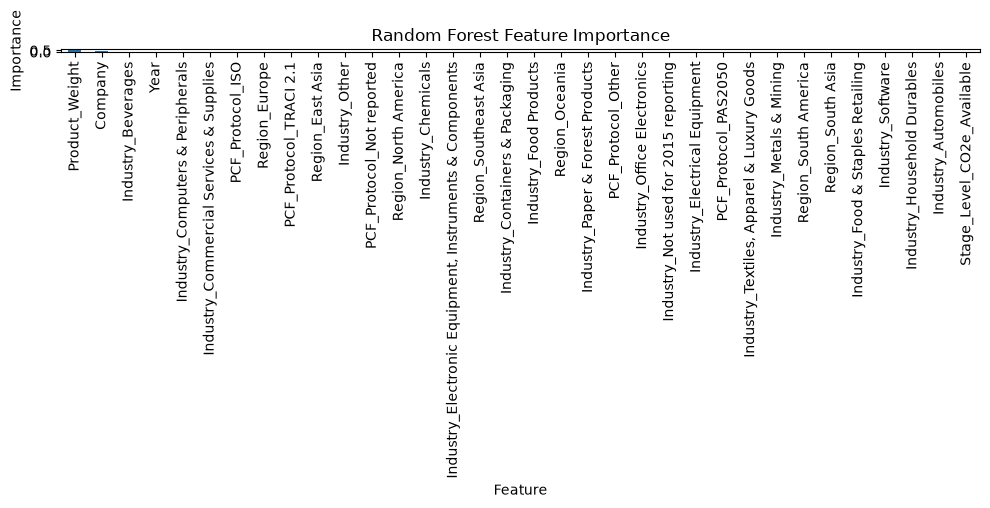

In [ ]:
import matplotlib.pyplot as plt

importance.plot(
    x="Feature",
    y="Importance",
    kind="bar",
    figsize=(10,5),
    legend=False
)

plt.title("Random Forest Feature Importance")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

In [ ]:
# Randomized Search for Random Forest

param_dist = {
    "n_estimators": [100, 200, 300, 400, 500],
    "max_depth": [10, 20, 30, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=30,    # Test 30 random combinations
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train_log)

print("Best Parameters:", random_search.best_params_)
print("Best CV Score:", random_search.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 20}
Best CV Score: 0.9150919040594838


In [ ]:
best_rf = random_search . best_estimator_

y_pred_log = best_rf.predict(X_test)

y_pred = np.expm1(y_pred_log)

In [ ]:
score = best_rf.score(X_test, y_test_log)

print(f"score:{score}")

score:0.8814803887794622


In [ ]:


mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2_original = r2_score(y_test, y_pred)

r2_log = r2_score(y_test_log, y_pred_log)

In [ ]:
print("=" * 60)
print("Random Forest(Randomized Search)")
print("=" * 60)

print(f"MAE (Original Scale)       : {mae:,.2f}")
print(f"RMSE (Original Scale)      : {rmse:,.2f}")
print(f"R² (Original Scale)        : {r2_original:.4f}")
print(f"R² (Log-transformed Scale) : {r2_log:.4f}")

Random Forest(Randomized Search)
MAE (Original Scale)       : 2,023.52
RMSE (Original Scale)      : 8,538.00
R² (Original Scale)        : 0.5196
R² (Log-transformed Scale) : 0.8815


In [ ]:
results.loc[len(results)] = [
    "Random forest (Randomized Search)",
    mae,
    rmse,
    r2_original,
    r2_log
]
results

,Model,MAE,RMSE,R2_Original,R2_Log
0,Linear Regression,10777.889157,104438.206531,-70.886024,0.642036
1,Ridge Regression,94236.544159,10378.101724,-57.528090,0.649315
2,Ridge Regression (grid search),10378.101724,94236.544159,-57.528090,0.649315
3,Ridge Regression(Randomized Search),10609.874195,97029.165858,-61.048351,0.649709
4,Random forest(Baseline),1881.311502,8220.716770,0.554605,0.941231
5,Random forest (Grid Search),1885.094006,8233.543949,0.553214,0.940210
6,Random forest (Randomized Search),2023.524552,8538.000017,0.519561,0.881480


# XG Boost


In [ ]:
pip install xgboost


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:

from xgboost import XGBRegressor



In [ ]:
xgb = XGBRegressor(
    objective="reg:squarederror"
)

In [ ]:
xgb.fit(
    X_train,
    y_train_log
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [ ]:
y_pred_log = xgb.predict(X_test)

y_pred = np.expm1(y_pred_log)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt( mean_squared_error(y_test, y_pred))

r2_original = r2_score( y_test, y_pred)

r2_log = r2_score(y_test_log,y_pred_log)

In [ ]:
print("=" * 60)
print("XGBoost (Baseline)")
print("=" * 60)

print(f"MAE (Original Scale)       : {mae:.2f}")
print(f"RMSE (Original Scale)      : {rmse:.2f}")
print(f"R² (Original Scale)        : {r2_original:.4f}")
print(f"R² (Log-transformed Scale) : {r2_log:.4f}")

XGBoost (Baseline)
MAE (Original Scale)       : 1898.45
RMSE (Original Scale)      : 8495.55
R² (Original Scale)        : 0.5243
R² (Log-transformed Scale) : 0.9397


In [ ]:
results.loc[len(results)] = [
    "XGBoost (Baseline)",
    mae,
    rmse,
    r2_original,
    r2_log
]

results

,Model,MAE,RMSE,R2_Original,R2_Log
0,Linear Regression,10777.889157,104438.206531,-70.886024,0.642036
1,Ridge Regression,94236.544159,10378.101724,-57.528090,0.649315
2,Ridge Regression (grid search),10378.101724,94236.544159,-57.528090,0.649315
3,Ridge Regression(Randomized Search),10609.874195,97029.165858,-61.048351,0.649709
4,Random forest(Baseline),1881.311502,8220.716770,0.554605,0.941231
5,Random forest (Grid Search),1885.094006,8233.543949,0.553214,0.940210
6,Random forest (Randomized Search),2023.524552,8538.000017,0.519561,0.881480
7,XGBoost (Baseline),1898.450092,8495.545380,0.524327,0.939692


In [ ]:
#randomized Search for XGBoost

param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [3, 5, 7, 10],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "min_child_weight": [1, 3, 5]
}

random_search = RandomizedSearchCV(
    estimator=XGBRegressor(
        objective="reg:squarederror"
    ),
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(
    X_train,
    y_train_log
)

print("Best Parameters:", random_search.best_params_)
print("Best CV Score:", random_search.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters: {'subsample': 0.8, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
Best CV Score: 0.9336500751371846


In [ ]:
best_xgb = random_search.best_estimator_

y_pred_log = best_xgb.predict(X_test)

y_pred = np.expm1(y_pred_log)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2_original = r2_score(y_test, y_pred)
r2_log = r2_score(y_test_log, y_pred_log)


In [ ]:
print("=" * 60)
print("XGBoost (Randomized Search)")
print("=" * 60)

print(f"MAE (Original Scale)       : {mae:.2f}")
print(f"RMSE (Original Scale)      : {rmse:.2f}")
print(f"R² (Original Scale)        : {r2_original:.4f}")
print(f"R² (Log-transformed Scale) : {r2_log:.4f}")

XGBoost (Randomized Search)
MAE (Original Scale)       : 1983.12
RMSE (Original Scale)      : 8436.66
R² (Original Scale)        : 0.5309
R² (Log-transformed Scale) : 0.9344


In [ ]:

results.loc[len(results)] = [
    "XGBoost (Randomized Search)",
    mae,
    rmse,
    r2_original,
    r2_log
]

In [ ]:
#grid search for XGBoost
param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.1, 0.2],
    "max_depth": [3, 5, 7],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}
grid = GridSearchCV(
    estimator = XGBRegressor(
            objective="reg:squarederror"
        ),
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

grid.fit(
    X_train,
    y_train_log
)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.01, 0.1, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_a

In [ ]:
print("Best Parameters:")
print(grid.best_params_)

print("\nBest CV Score:")
print(grid.best_score_)

Best Parameters:
{'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}

Best CV Score:
0.9345749647802117


In [ ]:
best_xgb = grid.best_estimator_
y_pred_log = best_xgb.predict(X_test)

y_pred = np.expm1(y_pred_log)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2_original = r2_score(y_test, y_pred)

r2_log = r2_score(y_test_log, y_pred_log)

In [ ]:
print("=" * 60)
print("XGBoost (grid Search)")
print("=" * 60)

print(f"MAE (Original Scale)       : {mae:.2f}")
print(f"RMSE (Original Scale)      : {rmse:.2f}")
print(f"R² (Original Scale)        : {r2_original:.4f}")
print(f"R² (Log-transformed Scale) : {r2_log:.4f}")

XGBoost (grid Search)
MAE (Original Scale)       : 1925.03
RMSE (Original Scale)      : 8386.07
R² (Original Scale)        : 0.5365
R² (Log-transformed Scale) : 0.9272


In [ ]:
results.loc[len(results)] = [
    "XGBoost (GridSearchCV)",
    mae,
    rmse,
    r2_original,
    r2_log
]

results

,Model,MAE,RMSE,R2_Original,R2_Log
0,Linear Regression,10777.889157,104438.206531,-70.886024,0.642036
1,Ridge Regression,94236.544159,10378.101724,-57.528090,0.649315
2,Ridge Regression (grid search),10378.101724,94236.544159,-57.528090,0.649315
3,Ridge Regression(Randomized Search),10609.874195,97029.165858,-61.048351,0.649709
4,Random forest(Baseline),1881.311502,8220.716770,0.554605,0.941231
5,Random forest (Grid Search),1885.094006,8233.543949,0.553214,0.940210
6,Random forest (Randomized Search),2023.524552,8538.000017,0.519561,0.881480
7,XGBoost (Baseline),1898.450092,8495.545380,0.524327,0.939692
8,XGBoost (Randomized Search),1983.119349,8436.656900,0.530899,0.934449
9,XGBoost (GridSearchCV),1925.033906,8386.072564,0.536507,0.927229


# CAT Boost

In [ ]:
%pip install catboost


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:

from catboost import CatBoostRegressor


In [ ]:
cat = CatBoostRegressor()


In [ ]:
cat.fit(
    X_train,
    y_train_log
)

Learning rate set to 0.038629
0:	learn: 3.1979334	total: 1.04ms	remaining: 1.04s
1:	learn: 3.1138495	total: 1.44ms	remaining: 721ms
2:	learn: 3.0304895	total: 2.18ms	remaining: 725ms
3:	learn: 2.9505181	total: 3.04ms	remaining: 757ms
4:	learn: 2.8732194	total: 3.73ms	remaining: 742ms
5:	learn: 2.7928152	total: 4.29ms	remaining: 712ms
6:	learn: 2.7193730	total: 5.14ms	remaining: 729ms
7:	learn: 2.6554829	total: 5.73ms	remaining: 710ms
8:	learn: 2.5888202	total: 6.39ms	remaining: 704ms
9:	learn: 2.5222122	total: 7.28ms	remaining: 720ms
10:	learn: 2.4582926	total: 8.2ms	remaining: 738ms
11:	learn: 2.3951334	total: 9.03ms	remaining: 743ms
12:	learn: 2.3393353	total: 9.76ms	remaining: 741ms
13:	learn: 2.2835701	total: 11.7ms	remaining: 826ms
14:	learn: 2.2316492	total: 12.3ms	remaining: 808ms
15:	learn: 2.1798824	total: 12.8ms	remaining: 790ms
16:	learn: 2.1320404	total: 13.4ms	remaining: 774ms
17:	learn: 2.0904149	total: 13.9ms	remaining: 758ms
18:	learn: 2.0481252	total: 14.4ms	remaining:

CatBoostRegressor(loss_function='RMSE')

In [ ]:
y_pred_log = cat.predict(X_test)

y_pred = np.expm1(y_pred_log)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt( mean_squared_error(y_test, y_pred))

r2_original = r2_score(y_test, y_pred)

r2_log = r2_score(y_test_log,y_pred_log)

In [ ]:
print("=" * 60)
print("CatBoost (Baseline)")
print("=" * 60)

print(f"MAE (Original Scale)       : {mae:.2f}")
print(f"RMSE (Original Scale)      : {rmse:.2f}")
print(f"R² (Original Scale)        : {r2_original:.4f}")
print(f"R² (Log-transformed Scale) : {r2_log:.4f}")

CatBoost (Baseline)
MAE (Original Scale)       : 2041.55
RMSE (Original Scale)      : 8596.80
R² (Original Scale)        : 0.5129
R² (Log-transformed Scale) : 0.9110


In [ ]:
results.loc[len(results)] = [
    "CatBoost (Baseline)",
    mae,
    rmse,
    r2_original,
    r2_log
]

results

,Model,MAE,RMSE,R2_Original,R2_Log
0,Linear Regression,10777.889157,104438.206531,-70.886024,0.642036
1,Ridge Regression,94236.544159,10378.101724,-57.528090,0.649315
2,Ridge Regression (grid search),10378.101724,94236.544159,-57.528090,0.649315
3,Ridge Regression(Randomized Search),10609.874195,97029.165858,-61.048351,0.649709
4,Random forest(Baseline),1881.311502,8220.716770,0.554605,0.941231
5,Random forest (Grid Search),1885.094006,8233.543949,0.553214,0.940210
6,Random forest (Randomized Search),2023.524552,8538.000017,0.519561,0.881480
7,XGBoost (Baseline),1898.450092,8495.545380,0.524327,0.939692
8,XGBoost (Randomized Search),1983.119349,8436.656900,0.530899,0.934449
9,XGBoost (GridSearchCV),1925.033906,8386.072564,0.536507,0.927229


In [ ]:
# Grid Search for CatBoost

param_grid = {
    "iterations": [100, 200, 300],
    "depth": [4, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1]
}

grid = GridSearchCV(
    estimator=CatBoostRegressor(),
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1

)

grid.fit(
    X_train,
    y_train_log
)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

0:	learn: 3.2758047	total: 46.2ms	remaining: 4.57s
1:	learn: 3.2511894	total: 46.5ms	remaining: 2.28s
2:	learn: 3.2278027	total: 46.8ms	remaining: 1.51s
3:	learn: 3.2064492	total: 47.2ms	remaining: 1.13s
4:	learn: 3.1853487	total: 47.5ms	remaining: 902ms
5:	learn: 3.1634016	total: 47.8ms	remaining: 749ms
0:	learn: 3.2373226	total: 47.6ms	remaining: 4.71s
6:	learn: 3.1426242	total: 49.6ms	remaining: 659ms
1:	learn: 3.2149921	total: 48.3ms	remaining: 2.36s
7:	learn: 3.1220852	total: 50ms	remaining: 575ms
8:	learn: 3.1014121	total: 50.3ms	remaining: 509ms
2:	learn: 3.1916142	total: 48.6ms	remaining: 1.57s
9:	learn: 3.0812436	total: 50.6ms	remaining: 456ms
3:	learn: 3.1693085	total: 49ms	remaining: 1.18s
10:	learn: 3.0590480	total: 51ms	remaining: 412ms
4:	learn: 3.1480050	total: 49.3ms	remaining: 937ms
11:	learn: 3.0394431	total: 51.3ms	remaining: 376ms
5:	learn: 3.1264880	total: 49.6ms	remaining: 777ms
12:	learn: 3.0186906	total: 51.6ms	remaining: 345ms
6:	learn: 3.1051107	total: 49.9ms	

In [ ]:
best_cat = grid.best_estimator_

y_pred_log = best_cat.predict(X_test)

y_pred = np.expm1(y_pred_log)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2_original = r2_score(y_test, y_pred)

r2_log = r2_score(y_test_log, y_pred_log)

In [ ]:
print("=" * 60)
print("CatBoost (Baseline)")
print("=" * 60)

print(f"MAE (Original Scale)       : {mae:.2f}")
print(f"RMSE (Original Scale)      : {rmse:.2f}")
print(f"R² (Original Scale)        : {r2_original:.4f}")
print(f"R² (Log-transformed Scale) : {r2_log:.4f}")

CatBoost (Baseline)
MAE (Original Scale)       : 2024.03
RMSE (Original Scale)      : 8859.93
R² (Original Scale)        : 0.4826
R² (Log-transformed Scale) : 0.9122


In [ ]:
results.loc[len(results)] = [
    "CatBoost (GridSearchCV)",
    mae,
    rmse,
    r2_original,
    r2_log
]

results

,Model,MAE,RMSE,R2_Original,R2_Log
0,Linear Regression,10777.889157,104438.206531,-70.886024,0.642036
1,Ridge Regression,94236.544159,10378.101724,-57.528090,0.649315
2,Ridge Regression (grid search),10378.101724,94236.544159,-57.528090,0.649315
3,Ridge Regression(Randomized Search),10609.874195,97029.165858,-61.048351,0.649709
4,Random forest(Baseline),1881.311502,8220.716770,0.554605,0.941231
5,Random forest (Grid Search),1885.094006,8233.543949,0.553214,0.940210
6,Random forest (Randomized Search),2023.524552,8538.000017,0.519561,0.881480
7,XGBoost (Baseline),1898.450092,8495.545380,0.524327,0.939692
8,XGBoost (Randomized Search),1983.119349,8436.656900,0.530899,0.934449
9,XGBoost (GridSearchCV),1925.033906,8386.072564,0.536507,0.927229


In [ ]:
#Randomized Search for CatBoost

param_dist = {
    "iterations": [100, 200, 300, 500],
    "depth": [4, 6, 8, 10],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "l2_leaf_reg": [1, 3, 5, 7, 9],
    "subsample": [0.8, 1.0]
}

random_search = RandomizedSearchCV(
    estimator=CatBoostRegressor(),
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(
    X_train,
    y_train_log
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
0:	learn: 3.1859166	total: 15.4ms	remaining: 4.61s
0:	learn: 3.1464344	total: 21.9ms	remaining: 6.55s
1:	learn: 3.0842972	total: 24.5ms	remaining: 3.65s
2:	learn: 2.9790500	total: 25.1ms	remaining: 2.49s
1:	learn: 3.0437780	total: 31.4ms	remaining: 4.67s
2:	learn: 2.9364108	total: 32ms	remaining: 3.17s
3:	learn: 2.8306413	total: 43.8ms	remaining: 3.24s
3:	learn: 2.8801328	total: 34.5ms	remaining: 2.56s
4:	learn: 2.7366313	total: 52.8ms	remaining: 3.12s
4:	learn: 2.7844009	total: 42.9ms	remaining: 2.53s
5:	learn: 2.6466622	total: 60.8ms	remaining: 2.98s
5:	learn: 2.6997204	total: 51.3ms	remaining: 2.51s
6:	learn: 2.5621247	total: 68.5ms	remaining: 2.87s
6:	learn: 2.6164062	total: 63ms	remaining: 2.63s
7:	learn: 2.4843915	total: 76.2ms	remaining: 2.78s
8:	learn: 2.4126364	total: 76.9ms	remaining: 2.49s
7:	learn: 2.5364470	total: 69.5ms	remaining: 2.54s
9:	learn: 2.3343370	total: 79.3ms	remaining: 2.3s
8:	learn: 2.4683609	total

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",CatBoostRegre...nction='RMSE')
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'depth': [4, 6, ...], 'iterations': [100, 200, ...], 'l2_leaf_reg': [1, 3, ...], 'learning_rate': [0.01, 0.05, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selec

In [ ]:
print("Best Parameters:")
print(random_search.best_params_)

print("\nBest CV Score:")
print(random_search.best_score_)

Best Parameters:
{'subsample': 1.0, 'learning_rate': 0.05, 'l2_leaf_reg': 3, 'iterations': 500, 'depth': 6}

Best CV Score:
0.9305770634698198


In [ ]:
best_cat = random_search.best_estimator_

In [ ]:
y_pred_log = best_cat.predict(X_test)

y_pred = np.expm1(y_pred_log)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2_original = r2_score(y_test, y_pred)

r2_log = r2_score(y_test_log, y_pred_log)

In [ ]:
print("=" * 60)
print("CatBoost (RandomizedSearchCV)")
print("=" * 60)

print(f"MAE (Original Scale)       : {mae:.2f}")
print(f"RMSE (Original Scale)      : {rmse:.2f}")
print(f"R² (Original Scale)        : {r2_original:.4f}")
print(f"R² (Log-transformed Scale) : {r2_log:.4f}")

CatBoost (RandomizedSearchCV)
MAE (Original Scale)       : 2068.39
RMSE (Original Scale)      : 8588.39
R² (Original Scale)        : 0.5139
R² (Log-transformed Scale) : 0.9020


In [ ]:
results.loc[len(results)] = [
    "CatBoost (RandomizedSearchCV)",
    mae,
    rmse,
    r2_original,
    r2_log
]

results

,Model,MAE,RMSE,R2_Original,R2_Log
0,Linear Regression,10777.889157,104438.206531,-70.886024,0.642036
1,Ridge Regression,94236.544159,10378.101724,-57.528090,0.649315
2,Ridge Regression (grid search),10378.101724,94236.544159,-57.528090,0.649315
3,Ridge Regression(Randomized Search),10609.874195,97029.165858,-61.048351,0.649709
4,Random forest(Baseline),1881.311502,8220.716770,0.554605,0.941231
5,Random forest (Grid Search),1885.094006,8233.543949,0.553214,0.940210
6,Random forest (Randomized Search),2023.524552,8538.000017,0.519561,0.881480
7,XGBoost (Baseline),1898.450092,8495.545380,0.524327,0.939692
8,XGBoost (Randomized Search),1983.119349,8436.656900,0.530899,0.934449
9,XGBoost (GridSearchCV),1925.033906,8386.072564,0.536507,0.927229
